<a href="https://colab.research.google.com/github/main-polyboly/01_IntroPython_TapiaBarbara./blob/main/Auditor%C3%ADa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: Auditoría de Desempeño para Negocios Digitales

Estudiante: Barbara Tapia
Profesor: Iván Herrera


## Parte 1: Análisis de datos sintéticos

En esta parte analizamos un dataset de transacciones para determinar si la estrategia de M-Commerce (App Móvil) es más rentable que el E-Commerce tradicional (Web Desktop). Para ello generamos una base de datos aleatoria que simula la salida de un TPS.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

# Generar datos simulados
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}

df = pd.DataFrame(data)

df

,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,App Móvil,Tarjeta Crédito,96,Moda
1,1002,App Móvil,Tarjeta Crédito,438,Electrónica
2,1003,Web Desktop,Transferencia,86,Hogar
3,1004,Web Desktop,Transferencia,56,Moda
4,1005,Web Desktop,Tarjeta Crédito,286,Hogar
5,1006,App Móvil,Transferencia,481,Electrónica
6,1007,App Móvil,Transferencia,224,Moda
7,1008,Web Desktop,Tarjeta Crédito,200,Electrónica
8,1009,Web Desktop,Tarjeta Crédito,105,Moda
9,1010,Web Desktop,Tarjeta Crédito,270,Electrónica


### ¿Qué preguntas deberíamos plantearnos para obtener las respuestas que buscamos?

Para determinar si la estrategia de **M-Commerce (App Móvil)** es más rentable que el **E-Commerce tradicional (Web Desktop)**, nuestro MIS debe responder a las siguientes 4 preguntas clave (nuestros KPIs):

1. **Ingresos Totales por Canal:** ¿Qué plataforma genera el mayor volumen de ventas brutas?
2. **Ticket Promedio de Compra:** ¿En qué plataforma los usuarios gastan más dinero por transacción?
3. **Volumen de Transacciones:** ¿Qué canal tiene la mayor tracción y frecuencia de uso?
4. **Preferencia de Pago:** ¿Cómo se distribuye el uso de métodos de pago en cada canal y afecta esto a la rentabilidad?

In [ ]:
# Volumen de Transacciones por Canal
volumen_transacciones = df['Canal'].value_counts()

# Ingresos Totales por Canal
ingresos_totales = df.groupby('Canal')['Total_Venta'].sum()

# Ticket Promedio por Canal (AOV)
ticket_promedio = df.groupby('Canal')['Total_Venta'].mean()

# Porcentaje de Participación en Ingresos
ingreso_total_global = df['Total_Venta'].sum()
participacion_ingresos = (ingresos_totales / ingreso_total_global) * 100

# Consolidación de métricas en un Dashboard para el MIS
mis_dashboard_p1 = pd.DataFrame({
    'Transacciones (U)': volumen_transacciones,
    'Ingresos Totales ($)': ingresos_totales,
    'Ticket Promedio ($)': ticket_promedio.round(2),
    'Participación de Ingresos (%)': participacion_ingresos.round(2)
})

# Ordenar por rentabilidad absoluta (Ingresos Totales)
mis_dashboard_p1 = mis_dashboard_p1.sort_values(by='Ingresos Totales ($)', ascending=False)
mis_dashboard_p1

,Transacciones (U),Ingresos Totales ($),Ticket Promedio ($),Participación de Ingresos (%)
Canal,,,,
App Móvil,28,7717,275.61,59.83
Web Desktop,22,5181,235.50,40.17


###  KPIs de rentabilidad M-commerce vs E- commerce

/tmp/ipykernel_663/175804264.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Canal', y='Total_Venta', data=ventas_totales, ax=axes[0, 0], palette='Blues_r')
/tmp/ipykernel_663/175804264.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Canal', y='Total_Venta', data=ticket_promedio, ax=axes[0, 1], palette='Greens_r')
/tmp/ipykernel_663/175804264.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Canal', data=df, ax=axes[1, 0], palette='Purples_r')


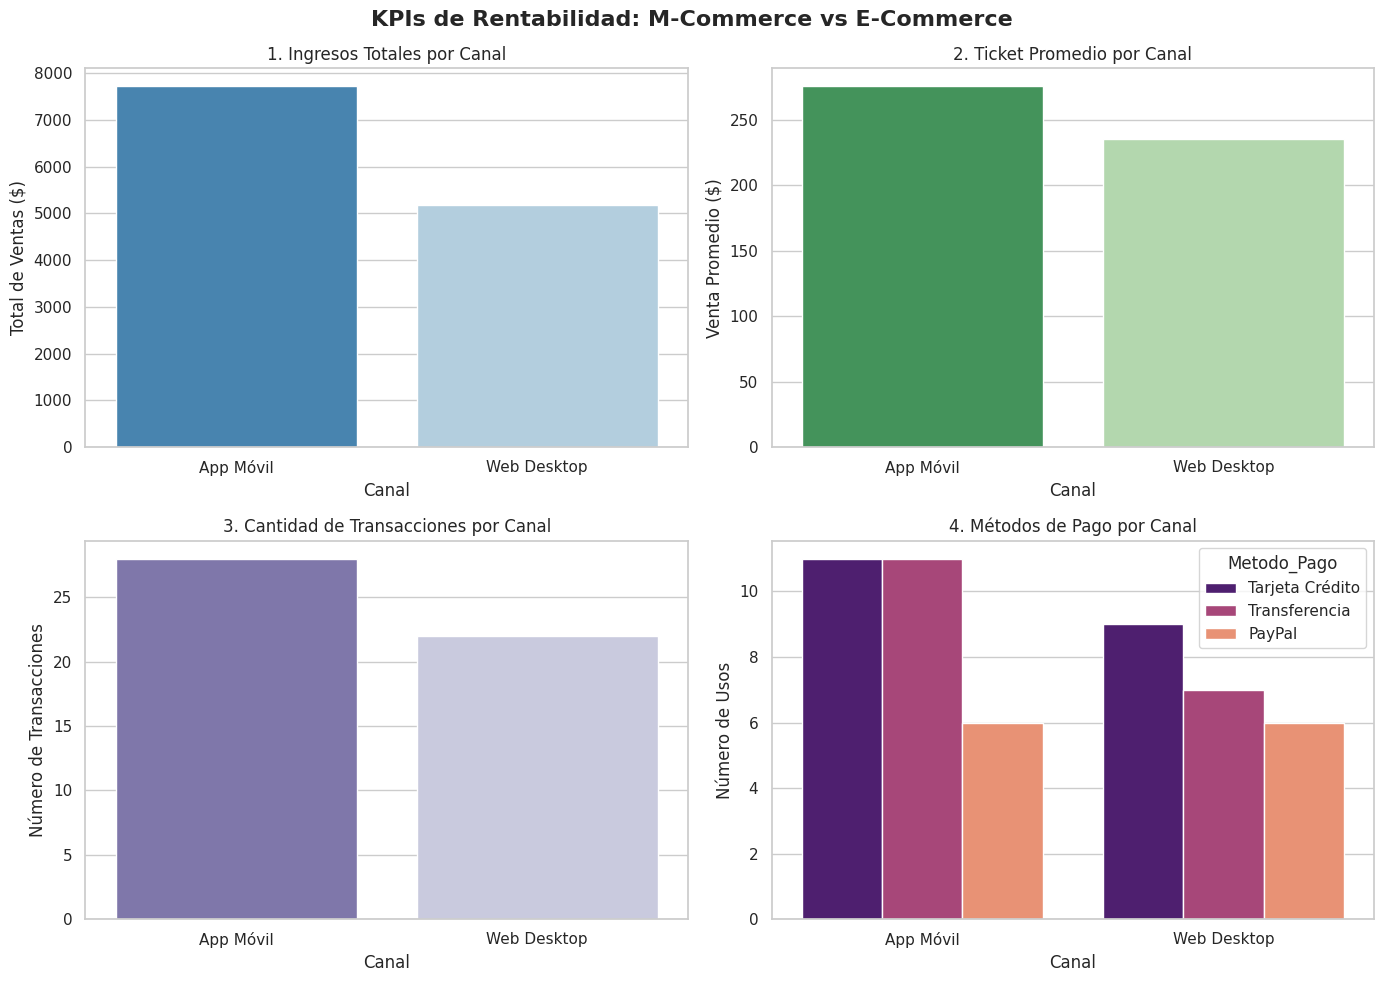

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para el Dashboard
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('KPIs de Rentabilidad: M-Commerce vs E-Commerce', fontsize=16, fontweight='bold')

# KPI 1: Ingresos Totales por Canal
ventas_totales = df.groupby('Canal')['Total_Venta'].sum().reset_index()
sns.barplot(x='Canal', y='Total_Venta', data=ventas_totales, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('1. Ingresos Totales por Canal')
axes[0, 0].set_ylabel('Total de Ventas ($)')

# KPI 2: Ticket Promedio por Canal
ticket_promedio = df.groupby('Canal')['Total_Venta'].mean().reset_index()
sns.barplot(x='Canal', y='Total_Venta', data=ticket_promedio, ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('2. Ticket Promedio por Canal')
axes[0, 1].set_ylabel('Venta Promedio ($)')

# KPI 3: Volumen de Transacciones por Canal
sns.countplot(x='Canal', data=df, ax=axes[1, 0], palette='Purples_r')
axes[1, 0].set_title('3. Cantidad de Transacciones por Canal')
axes[1, 0].set_ylabel('Número de Transacciones')

# KPI 4: Métodos de Pago por Canal
sns.countplot(x='Canal', hue='Metodo_Pago', data=df, ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('4. Métodos de Pago por Canal')
axes[1, 1].set_ylabel('Número de Usos')

plt.tight_layout()
plt.show()

### 1.- KPIs de Gestión de Logística y Operaciones (Shipment & Warehouse)

In [ ]:
# Costo Promedio del Producto por Modo de Transporte
costo_por_transporte = data_ecommerce.groupby('Mode_of_Shipment')['Cost_of_the_Product'].mean().round(2)

# Volumen de Ocupación por Bloque de Bodega
ocupacion_bodega = (data_ecommerce['Warehouse_block'].value_counts(normalize=True) * 100).round(2)

# Peso Promedio del Producto por Modo de Envío
peso_por_envio = data_ecommerce.groupby('Mode_of_Shipment')['Weight_in_gms'].mean().round(2)

# Construcción de DataFrame resumen para Logística
logistica_df = pd.DataFrame({
    'Costo Promedio del Producto ($)': costo_por_transporte,
    'Peso Promedio (gms)': peso_por_envio
})

print("--- Ocupación por Bloque de Bodega (%) ---")
print(ocupacion_bodega)
print("\n--- Análisis de Envío y Costos ---")
logistica_df

--- Ocupación por Bloque de Bodega (%) ---
Warehouse_block
F    33.33
D    16.67
A    16.67
B    16.67
C    16.67
Name: proportion, dtype: float64

--- Análisis de Envío y Costos ---


,Costo Promedio del Producto ($),Peso Promedio (gms)
Mode_of_Shipment,,
Flight,209.31,3629.38
Road,210.48,3649.55
Ship,210.34,3631.46


/tmp/ipykernel_663/2353645240.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mode_of_Shipment', y='Cost_of_the_Product', data=data_ecommerce, ax=axes[0], errorbar=None, palette='coolwarm')
/tmp/ipykernel_663/2353645240.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Warehouse_block', data=data_ecommerce, ax=axes[1], order=['A', 'B', 'C', 'D', 'F'], palette='Set2')
/tmp/ipykernel_663/2353645240.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mode_of_Shipment', y='Weight_in_gms', data=data_ecommerce, ax=axes[2], error

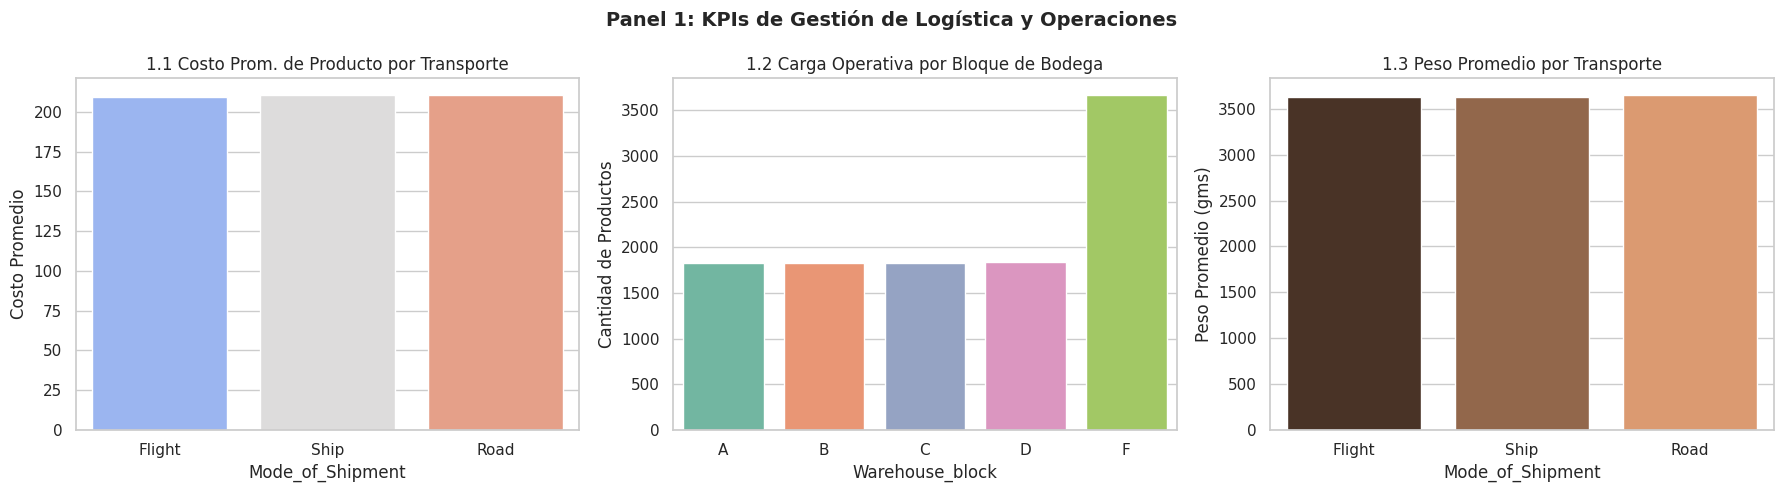

In [25]:
# Gráficos para Logística y Operaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Panel 1: KPIs de Gestión de Logística y Operaciones', fontsize=14, fontweight='bold')

# 1.1 Costo Prom. Producto por Transporte (Proxy de impacto financiero)
sns.barplot(x='Mode_of_Shipment', y='Cost_of_the_Product', data=data_ecommerce, ax=axes[0], errorbar=None, palette='coolwarm')
axes[0].set_title('1.1 Costo Prom. de Producto por Transporte')
axes[0].set_ylabel('Costo Promedio')

# 1.2 Volumen de Ocupación por Bloque de Bodega
sns.countplot(x='Warehouse_block', data=data_ecommerce, ax=axes[1], order=['A', 'B', 'C', 'D', 'F'], palette='Set2')
axes[1].set_title('1.2 Carga Operativa por Bloque de Bodega')
axes[1].set_ylabel('Cantidad de Productos')

# 1.3 Peso Promedio del Producto por Modo de Envío
sns.barplot(x='Mode_of_Shipment', y='Weight_in_gms', data=data_ecommerce, ax=axes[2], errorbar=None, palette='copper')
axes[2].set_title('1.3 Peso Promedio por Transporte')
axes[2].set_ylabel('Peso Promedio (gms)')

plt.tight_layout()
plt.show()

### 2.- KPIs de Gestión Comercial y Financiera (Sales & Revenue)

In [ ]:
# Ingreso Total Bruto y Costo Promedio del Producto
ingreso_total = data_ecommerce['Cost_of_the_Product'].sum()
costo_promedio_global = data_ecommerce['Cost_of_the_Product'].mean().round(2)

# Porcentaje de Descuento Promedio Otorgado
descuento_promedio = data_ecommerce['Discount_offered'].mean().round(2)

# Margen Teórico Relativo por Importancia del Producto
comercial_por_importancia = data_ecommerce.groupby('Product_importance')[['Cost_of_the_Product', 'Discount_offered']].mean().round(2)

print(f"Ingreso Total Bruto de la Operación: ${ingreso_total:,}")
print(f"Costo Promedio Global por Producto: ${costo_promedio_global}")
print(f"Porcentaje de Descuento Promedio Global: {descuento_promedio}%\n")
print("--- Análisis por Nivel de Importancia de Producto ---")
comercial_por_importancia

Ingreso Total Bruto de la Operación: $2,311,955
Costo Promedio Global por Producto: $210.2
Porcentaje de Descuento Promedio Global: 13.37%

--- Análisis por Nivel de Importancia de Producto ---


,Cost_of_the_Product,Discount_offered
Product_importance,,
high,203.87,14.67
low,212.06,13.04
medium,209.38,13.48


/tmp/ipykernel_663/3678124046.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Prior_purchases', y='Discount_offered', data=data_ecommerce, ax=axes[1], errorbar=None, palette='YlOrBr')
/tmp/ipykernel_663/3678124046.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Product_importance', y='Cost_of_the_Product', data=data_ecommerce, ax=axes[2], order=['low', 'medium', 'high'], errorbar=None, palette='rocket')


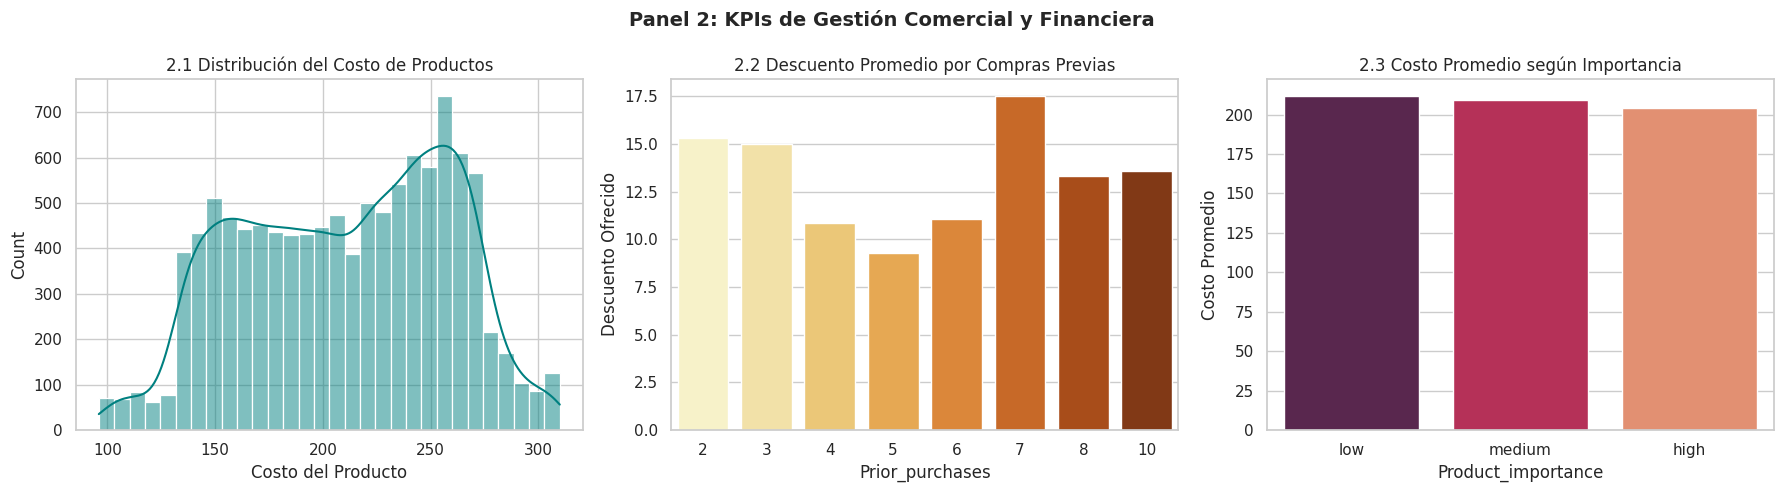

In [27]:
# Gráficos para Ventas y Finanzas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Panel 2: KPIs de Gestión Comercial y Financiera', fontsize=14, fontweight='bold')

# 2.1 Distribución del Costo (Ticket promedio y dispersión)
sns.histplot(data_ecommerce['Cost_of_the_Product'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('2.1 Distribución del Costo de Productos')
axes[0].set_xlabel('Costo del Producto')

# 2.2 Descuento Promedio por Nivel de Compras Previas (Fidelidad)
sns.barplot(x='Prior_purchases', y='Discount_offered', data=data_ecommerce, ax=axes[1], errorbar=None, palette='YlOrBr')
axes[1].set_title('2.2 Descuento Promedio por Compras Previas')
axes[1].set_ylabel('Descuento Ofrecido')

# 2.3 Margen vs Importancia del Producto
sns.barplot(x='Product_importance', y='Cost_of_the_Product', data=data_ecommerce, ax=axes[2], order=['low', 'medium', 'high'], errorbar=None, palette='rocket')
axes[2].set_title('2.3 Costo Promedio según Importancia')
axes[2].set_ylabel('Costo Promedio')

plt.tight_layout()
plt.show()

###3.- KPIs de Experiencia y Fidelización del Cliente (Customer Experience - CX)

In [ ]:
# Índice de Satisfacción del Cliente (CSAT) Promedio
csat_promedio = data_ecommerce['Customer_rating'].mean().round(2)

# Tasa de Retención / Clientes Recurrentes
# Se definen clientes recurrentes como aquellos con 2 o más compras previas
clientes_recurrentes = (data_ecommerce['Prior_purchases'] >= 2).sum()
total_clientes = len(data_ecommerce)
tasa_retencion = (clientes_recurrentes / total_clientes) * 100

# Carga de Soporte por Cliente (Customer Care Calls)
llamadas_soporte_promedio = data_ecommerce['Customer_care_calls'].mean().round(2)

# Consolidación de métricas de Experiencia de Cliente
cx_dashboard = pd.DataFrame({
    'Métrica CX': ['CSAT Promedio (1-5)', 'Tasa de Retención (%)', 'Promedio de Llamadas de Soporte'],
    'Valor': [csat_promedio, round(tasa_retencion, 2), llamadas_soporte_promedio]
})

cx_dashboard

,Métrica CX,Valor
0,CSAT Promedio (1-5),2.99
1,Tasa de Retención (%),100.00
2,Promedio de Llamadas de Soporte,4.05


/tmp/ipykernel_663/1523007801.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Customer_rating', data=data_ecommerce, ax=axes[0], errorbar=None, palette='pastel')
/tmp/ipykernel_663/1523007801.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Prior_purchases', data=data_ecommerce, ax=axes[1], palette='viridis')
/tmp/ipykernel_663/1523007801.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Customer_rating', y='Customer_care_calls', data=data_ecommerce, ax=axes[2], errorbar=None, palette='crest')


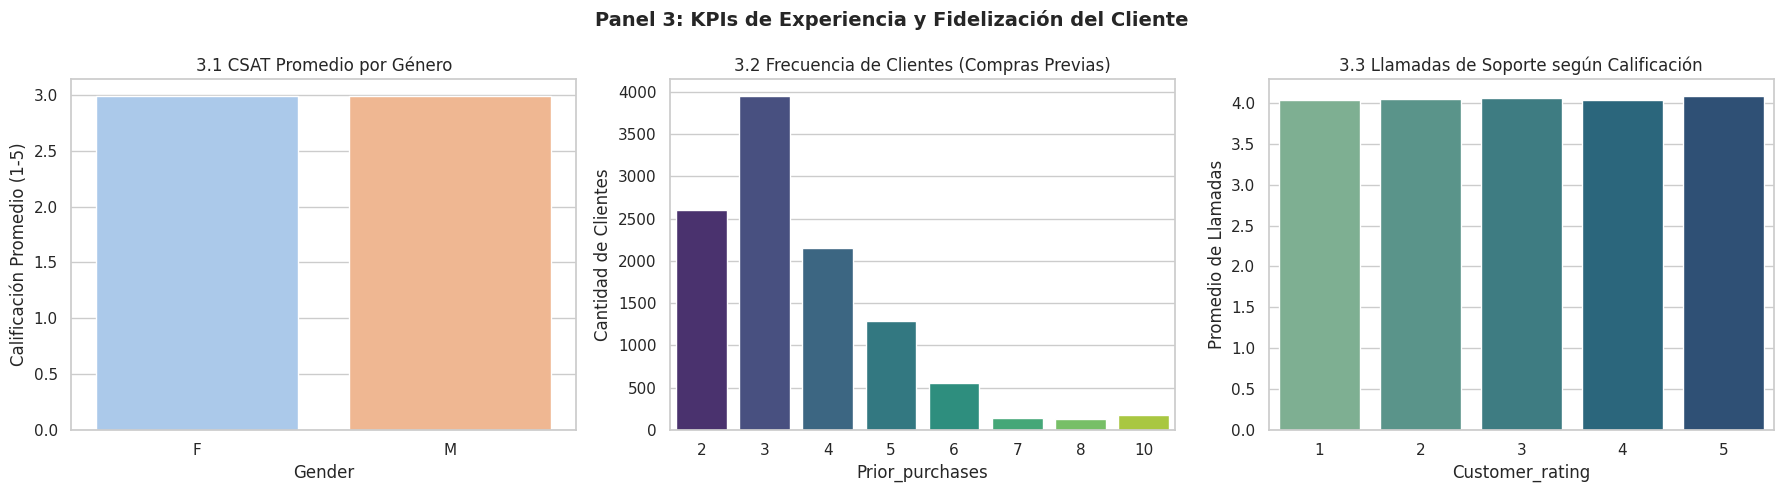

In [29]:
# Gráficos para Experiencia del Cliente (CX)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Panel 3: KPIs de Experiencia y Fidelización del Cliente', fontsize=14, fontweight='bold')

# 3.1 Índice de Satisfacción del Cliente (CSAT) por Género
sns.barplot(x='Gender', y='Customer_rating', data=data_ecommerce, ax=axes[0], errorbar=None, palette='pastel')
axes[0].set_title('3.1 CSAT Promedio por Género')
axes[0].set_ylabel('Calificación Promedio (1-5)')

# 3.2 Tasa de Retención (Distribución de historial de compras)
sns.countplot(x='Prior_purchases', data=data_ecommerce, ax=axes[1], palette='viridis')
axes[1].set_title('3.2 Frecuencia de Clientes (Compras Previas)')
axes[1].set_ylabel('Cantidad de Clientes')

# 3.3 Carga de Soporte: Llamadas vs Calificación CSAT
sns.barplot(x='Customer_rating', y='Customer_care_calls', data=data_ecommerce, ax=axes[2], errorbar=None, palette='crest')
axes[2].set_title('3.3 Llamadas de Soporte según Calificación')
axes[2].set_ylabel('Promedio de Llamadas')

plt.tight_layout()
plt.show()